In [114]:
import numpy as np
import statistics
import random
np.int=int
import pandas as pd
import os
import matplotlib.pyplot as plt

plt.style.use('default')


In [115]:
FILE_OUTPUT_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/cfa_spectra_pipeline/tests_on_real_glSNe/spectra_data/16geu'

<h1>
SNe True Ages

In [117]:
# Tmax of image 1 = 24 57 653.30 ± 0.33
# z = 0.4087

In [118]:
geu_data = pd.read_csv('/Users/pxm588@student.bham.ac.uk/PhD/cfa_spectra_pipeline/tests_on_real_glSNe/spectra_data/16geu/16geu_raw_data/wiserep_spectra.csv')

T_max = 2457653.30
z = 0.409

# Create the Phase column
geu_data['Phase'] = (geu_data['JD'] - T_max)/(1 + z)

geu_phase_data = geu_data[['Ascii file', 'Phase']].copy()

geu_phase_data.columns = ['filename', 'phase']
geu_phase_data['filename'] = geu_phase_data['filename'].str.rsplit('.', n=1).str[0]

geu_phase_data.to_csv('geu_spectra_phases.csv', index=False)

In [119]:
print(geu_phase_data)

                                             filename       phase
0         SN2016geu_2016-10-02_00-00-00_P60_SEDM_iPTF    7.239177
1           2016geu_2016-10-02_05-30-53_P60_SEDM_None    7.402257
2        SN2016geu_2016-10-04_00-00-00_P200_DBSP_iPTF    8.658623
3        SN2016geu_2016-10-06_00-00-00_P200_DBSP_iPTF   10.078070
4   SN2016geu_2016-10-09_02-31-02_ESO-NTT_EFOSC2-N...   12.281678
5   SN2016geu_2016-10-09_03-46-19_ESO-NTT_EFOSC2-N...   12.318782
6       SN2016geu_2016-10-09_21-42-05_NOT_ALFOSC_iPTF   12.848988
7   SN2016geu_2016-10-10_01-11-43_ESO-NTT_EFOSC2-N...   12.952309
8   SN2016geu_2016-10-10_02-14-16_ESO-NTT_EFOSC2-N...   12.983137
9                  2016geu_2457677.37_GTC_OSIRIS_None   17.083038
10          2016geu_2457679.50_VLT-UT2_X-Shooter_None   18.594748
11             2016geu_2457681.84_LDT_Deveny-LMI_None   20.255500
12               2016geu_2457686.83_Keck2_DEIMOS_None   23.797019
13                  2016geu_2457687.60_P200_DBSP_None   24.343506
14  2016ge

<h1>
Adding SNe suptypes

<h1>
SNR calculation

In [120]:
SPECTRA_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/cfa_spectra_pipeline/tests_on_real_glSNe/spectra_data/16geu/16geu_dereddened'

snr_data = []

for file in os.listdir(SPECTRA_DIR):
    file_path = os.path.join(SPECTRA_DIR, file)
    filename = os.path.splitext(file)[0]

    if file.lower().endswith('.csv'):
        continue

    data = np.genfromtxt(file_path, usecols=(0, 1), unpack=True, invalid_raise=False)
    wavelength, flux = data[0], data[1]

    redshift = 0.4087

    flux = flux[np.isfinite(flux)]
    flux = flux[flux != 0]

    noise = 1.2848 * np.median(np.abs(2.0 * flux[1:-1] - flux[0:-2] - flux[2:])) / np.sqrt(6.0)

    signal = np.median(flux)

    snr = signal / noise if noise > 0 else float('inf')

    snr_data.append({'filename': filename, 'snr': snr})

snr_df = pandas.DataFrame(snr_data)

In [121]:
print(snr_df)

                                             filename        snr
0                2016geu_2457686.83_Keck2_DEIMOS_None  46.375135
1   SN2016geu_2016-10-10_02-14-16_ESO-NTT_EFOSC2-N...   9.212648
2   2016geu_2016-10-30_00-14-24.00_VLT-UT2_X-Shoot...  23.320009
3   SN2016geu_2016-10-09_02-31-02_ESO-NTT_EFOSC2-N...  22.112218
4           2016geu_2457679.50_VLT-UT2_X-Shooter_None  20.929855
5         2016geu_2457691.51_VLT-UT2_X-Shooter_None_0  23.320009
6        SN2016geu_2016-10-04_00-00-00_P200_DBSP_iPTF  13.743874
7                  2016geu_2457677.37_GTC_OSIRIS_None  36.428263
8                   2016geu_2458627.96_P200_DBSP_None  20.011818
9                  2016geu_2457738.31_GTC_OSIRIS_None  46.907203
10      SN2016geu_2016-10-09_21-42-05_NOT_ALFOSC_iPTF  13.709039
11        SN2016geu_2016-10-02_00-00-00_P60_SEDM_iPTF  28.225502
12          2016geu_2016-10-02_05-30-53_P60_SEDM_None  28.225502
13             2016geu_2457681.84_LDT_Deveny-LMI_None   4.133513
14                 2016ge

<h2>
Bootstrapping

In [122]:
def calculate_bootstrap_median_topn(ages, rlaps, top_n):
    """
    Calculates the mean age and uncertainty by concatenating top fits from bootstrap samples.

    Returns:
        tuple: (standard deviation, mean age).
    """
    if len(ages) < top_n:
        return None, None

    if top_n == 0:
        return None, None

    trial_medians = []
    for _ in range(len(ages)):
        indices = random.choices(range(len(ages)), k=len(ages))
        random_ages = [ages[i] for i in indices]
        random_rlaps = [rlaps[i] for i in indices]

        sorted_pairs = sorted(zip(random_ages, random_rlaps), key=lambda x: x[1], reverse=True)

        if not sorted_pairs:
            continue

        top_pairs = sorted_pairs[:top_n]

        top_ages_from_sample = [pair[0] for pair in top_pairs]

        median_age = statistics.median(top_ages_from_sample)
        trial_medians.append(median_age)

    if len(trial_medians) < 2:
        return None, None

    final_median = statistics.median(trial_medians)
    final_stdev = statistics.stdev(trial_medians)

    return final_stdev, final_median


In [123]:
def parse_snid_file(filename):
    """
    Parses a SNID output file to extract all ages, rlaps, and redshifts
    until the rlap cutoff is reached.

    Args:
        filename (str): The path to the SNID output file.

    Returns:
        tuple: (list of ages, list of rlaps, list of redshifts) or (None, None, None) if parsing fails.
    """
    ages = []
    rlaps = []
    redshifts = []
    in_rlap_section = False

    try:
        with open(filename, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('### rlap-ordered template listings ###'):
                    in_rlap_section = True
                    next(f)  # Skip the header line
                    continue

                if in_rlap_section:
                    if line.startswith('#--- rlap cutoff'):
                        break
                    if line.startswith('#') or not line:
                        continue

                    parts = line.split()
                    if len(parts) > 9 and parts[9] == 'good':
                        try:
                            age = float(parts[7])
                            rlap = float(parts[4])
                            z = float(parts[5])
                            ages.append(age)
                            rlaps.append(rlap)
                            redshifts.append(z)
                        except (IndexError, ValueError) as e:
                            print(f"Could not parse line in {os.path.basename(filename)}: {line}\nError: {e}")
                            continue

    except FileNotFoundError:
        print(f"Error: The file '{filename}' was not found.")
        return None, None, None
    except Exception as e:
        print(f"An unexpected error occurred while reading {filename}: {e}")
        return None, None, None

    return (ages, rlaps, redshifts) if ages else (None, None, None)


In [124]:
OUTPUT_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/cfa_spectra_pipeline/tests_on_real_glSNe/spectra_data/16geu/16geu_snid_output'

bootstrap_results = []

for file in os.listdir(OUTPUT_DIR):
    file_path = os.path.join(OUTPUT_DIR, file)
    ages, rlaps, redshifts = parse_snid_file(file_path)

    filename = file.replace('_snid.output', '')

    std_dev, median = calculate_bootstrap_median_topn(ages, rlaps, 20)

    bootstrap_results.append({'filename': filename, 'SNID_age': median, 'SNID_age_err': std_dev})

bootstrap_df = pandas.DataFrame(bootstrap_results)


In [125]:
print(bootstrap_df)

                                             filename  SNID_age  SNID_age_err
0           2016geu_2016-10-02_05-30-53_P60_SEDM_None      7.55      1.174248
1   SN2016geu_2016-10-10_02-14-16_ESO-NTT_EFOSC2-N...     16.10      1.067633
2        SN2016geu_2016-10-06_00-00-00_P200_DBSP_iPTF      9.10      0.472182
3                   2016geu_2457687.60_P200_DBSP_None     26.25      1.271896
4                2016geu_2457686.83_Keck2_DEIMOS_None     22.60      0.907434
5         SN2016geu_2016-10-02_00-00-00_P60_SEDM_iPTF      7.45      1.251840
6       SN2016geu_2016-10-09_21-42-05_NOT_ALFOSC_iPTF     12.15      0.321956
7              2016geu_2457681.84_LDT_Deveny-LMI_None     28.20      2.160675
8                  2016geu_2457677.37_GTC_OSIRIS_None     20.00      0.873677
9   SN2016geu_2016-10-10_01-11-43_ESO-NTT_EFOSC2-N...     13.85      0.847551
10                 2016geu_2457694.74_Keck1_LRIS_None     30.18      2.146651
11  SN2016geu_2016-10-09_03-46-19_ESO-NTT_EFOSC2-N...     11.70 

<h1>
Merging all the dataframes

In [126]:
first_merge = pd.merge(snr_df, bootstrap_df, on='filename', how="left")

geu_final_data = pd.merge(first_merge, geu_phase_data, on='filename', how="left")

In [128]:
geu_final_data['residuals'] = geu_final_data['SNID_age'] - geu_final_data['phase']

<h2>
Plotting

In [151]:
OUTPUT_DIR = '/Users/pxm588@student.bham.ac.uk/PhD/cfa_spectra_pipeline/tests_on_real_glSNe/spectra_data/16geu'
STYLE_FILE = '../GausSN.mplstyle'

df_filtered = geu_final_data[(geu_final_data['snr'] >= 10)].copy()
df_filtered = df_filtered[(df_filtered['phase'] <= 40)].copy()

df_filtered.dropna(inplace=True)

                                             filename        snr  SNID_age  \
0                2016geu_2457686.83_Keck2_DEIMOS_None  46.375135     22.60   
3   SN2016geu_2016-10-09_02-31-02_ESO-NTT_EFOSC2-N...  22.112218     11.10   
6        SN2016geu_2016-10-04_00-00-00_P200_DBSP_iPTF  13.743874      8.60   
7                  2016geu_2457677.37_GTC_OSIRIS_None  36.428263     20.00   
10      SN2016geu_2016-10-09_21-42-05_NOT_ALFOSC_iPTF  13.709039     12.15   
11        SN2016geu_2016-10-02_00-00-00_P60_SEDM_iPTF  28.225502      7.45   
12          2016geu_2016-10-02_05-30-53_P60_SEDM_None  28.225502      7.55   
15                 2016geu_2457694.74_Keck1_LRIS_None  32.041047     30.18   
16  SN2016geu_2016-10-09_03-46-19_ESO-NTT_EFOSC2-N...  22.452621     11.70   
17                  2016geu_2457687.60_P200_DBSP_None  10.064766     26.25   
20       SN2016geu_2016-10-06_00-00-00_P200_DBSP_iPTF  20.839057      9.10   
21  SN2016geu_2016-10-10_01-11-43_ESO-NTT_EFOSC2-N...  23.206774

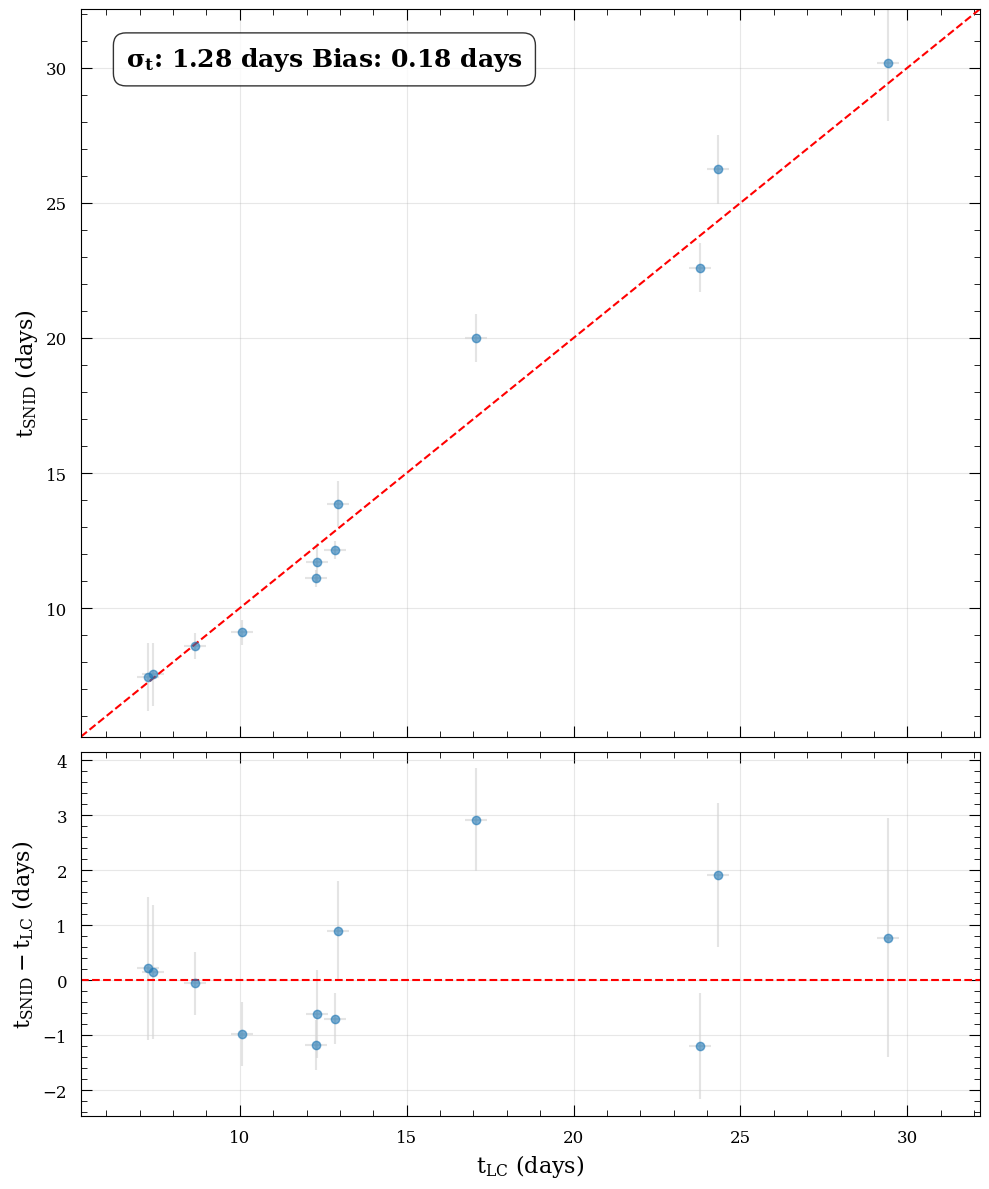

In [158]:
df_plot = df_filtered.copy()

# print(df_plot)

plt.style.use(STYLE_FILE)

print(df_plot)

sigma_t = df_plot['residuals'].std()
rmse = np.sqrt((df_plot['residuals']**2).mean())
bias = df_plot['residuals'].mean()

print(f"--- Statistics for Full Range Dataset (N={len(df_plot)}) ---")
print(f"Sigma_t (Dispersion): {sigma_t:.3f} days")
print(f"RMSE: {rmse:.3f} days")
print(f"Mean Bias: {bias:.3f} days")

df_plot['total_error'] = np.sqrt(df_plot['SNID_age_err']**2 + 0.33**2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Determine limits
all_ages = pd.concat([df_plot['phase'], df_plot['SNID_age']])

# print(all_ages)

min_age, max_age = all_ages.min() - 2, all_ages.max() + 2
min_age, max_age = all_ages.min() - 2, all_ages.max() + 2

# Top Panel: SNID Predicted Age vs True Age
ax1.errorbar(
    df_plot['phase'], df_plot['SNID_age'],
    yerr=df_plot['SNID_age_err'], xerr=0.33,
    fmt='o', alpha=0.6, ecolor='lightgray', capsize=0
)
ax1.plot([min_age, max_age], [min_age, max_age], color='red', linestyle='--')
ax1.set_ylabel(r"$t_{SNID}$ (days)")

metrics_text = fr"$\sigma_t$: {sigma_t:.2f} days Bias: {bias:.2f} days"

ax1.text(0.05, 0.95, metrics_text, transform=ax1.transAxes,
         va='top', ha='left', fontsize=18, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="black", alpha=0.8))

ax1.grid(True, alpha=0.3)
ax1.set_xlim(min_age, max_age)
ax1.set_ylim(min_age, max_age)

# Bottom Panel: Residuals
ax2.errorbar(
    df_plot['phase'], df_plot['residuals'],
    yerr=df_plot['total_error'], xerr=0.33,
    fmt='o', alpha=0.6, ecolor='lightgray', capsize=0
)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel(r"$t_{LC}$ (days)")
ax2.set_ylabel(r"$t_{SNID} - t_{LC}$ (days)")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(min_age, max_age)

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'snid_vs_true_correlation.png')
plt.savefig(plot_path, dpi=300)
print(f"Correlation plot saved to {plot_path}")
plt.show()

